In [6]:
import vrep 
import sys
import time 
import numpy as np
from tank import *
import skfuzzy as fuzz
from skfuzzy import control as ctrl


In [ ]:
def noAggressive(): 
    distance = ctrl.Antecedent(np.arange(0, 10, 0.01), 'distance')
    speed = ctrl.Consequent(np.arange(0, 11, 1), 'speed')

    speed['poor'] = fuzz.trimf(speed.universe, [0, 0, 5])
    speed['average'] = fuzz.trimf(speed.universe, [4, 5, 6])
    speed['good'] = fuzz.trimf(speed.universe, [5, 10, 10])

    distance['close'] = fuzz.trimf(distance.universe, [0, 0, 3])
    distance['medium'] = fuzz.trimf(distance.universe, [2, 5, 8])
    distance['far'] = fuzz.trimf(distance.universe, [7, 10, 10])

    print(distance.view())
    print(speed.view())

    rule1 = ctrl.Rule(distance['close'], speed['poor'])
    rule2 = ctrl.Rule(distance['medium'], speed['average'])
    rule3 = ctrl.Rule(distance['far'], speed['good'])

    tank_ctrl = ctrl.ControlSystem([rule1, rule2, rule3])
    tank_sim = ctrl.ControlSystemSimulation(tank_ctrl)

    return tank_sim

Connected to remote API server


KeyboardInterrupt: 

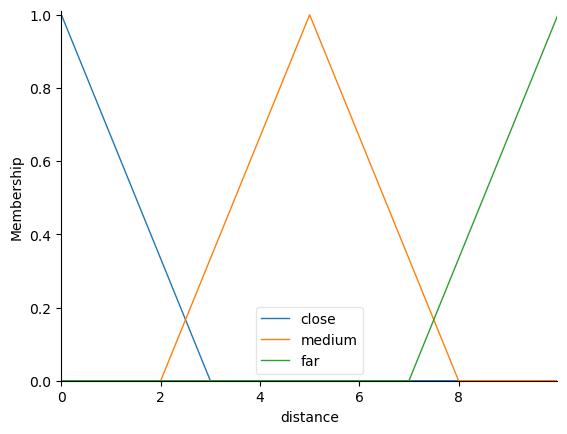

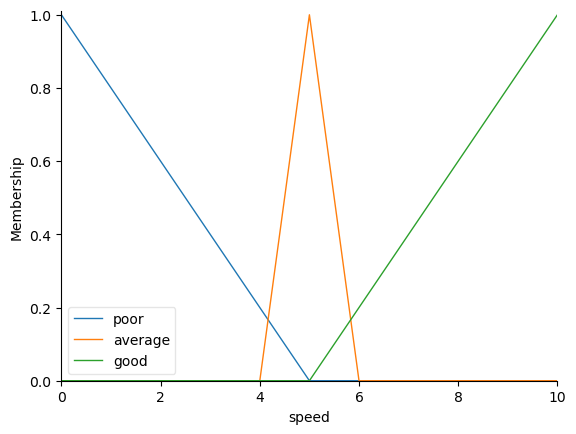

In [8]:
vrep.simxFinish(-1) # closes all opened connections, in case any prevoius wasnt finished
clientID=vrep.simxStart('127.0.0.1',19999,True,True,5000,5) # start a connection

if clientID!=-1:
    print ("Connected to remote API server")
else:
    print("Not connected to remote API server")
    sys.exit("Could not connect")

#create instance of Tank
tank=Tank(clientID)

# get handle to proximity sensor
err_code,ps_handle = vrep.simxGetObjectHandle(clientID,"Proximity_sensor", vrep.simx_opmode_blocking)

controller = noAggressive()

t = time.time()
while (time.time()-t)<100:
    err_code, detectionState, detectedPoint, detectedObjectHandle, detectedSurfaceNormalVector = vrep.simxReadProximitySensor(
        clientID, ps_handle, vrep.simx_opmode_streaming)
    if detectionState:
        dist = np.linalg.norm(detectedPoint).astype(np.float32)
        controller.input['distance'] = dist
        controller.compute()
        vel = controller.output['speed']
        tank.forward(velocity=vel)
        # print(f"Distance: {dist:.2f} m, speed: {vel:.2f}")
    else:
        tank.forward(velocity=10)
        # print("No obstacle detected, full speed")

vrep.simxStopSimulation(clientID,vrep.simx_opmode_oneshot) # stop the simulation in vrep